In [3]:
# --- Notebook setup cell ---
import sys, os

# get current working directory (for safety)
cwd = os.getcwd()
print("Current working directory:", cwd)

# if we’re running from inside notebooks/ or another subfolder,
# move up to project root so imports work
if "uuv_mission" not in os.listdir():
    os.chdir("..")
    print("Moved up to:", os.getcwd())

# add the project root to Python’s import path
sys.path.append(os.getcwd())

# verify
print("Python path now includes:", os.getcwd())


Current working directory: /Users/rufussadler/Documents/UniCoding/b1-coding-practical-mt25/uuv_mission
Moved up to: /Users/rufussadler/Documents/UniCoding/b1-coding-practical-mt25
Python path now includes: /Users/rufussadler/Documents/UniCoding/b1-coding-practical-mt25


In [1]:
import sys
print(sys.executable)


/Users/rufussadler/Documents/UniCoding/b1-coding-practical-mt25/.venv/bin/python


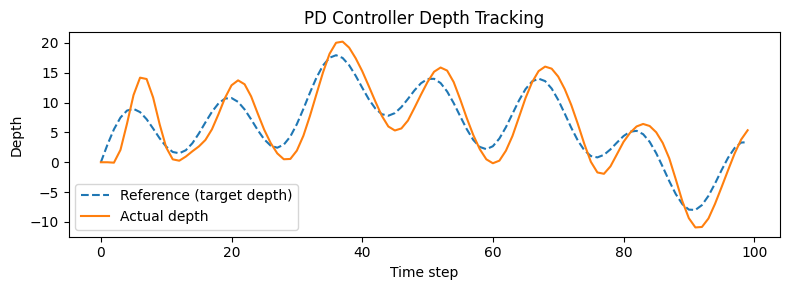

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
from uuv_mission.dynamic import Submarine, Mission, ClosedLoop
from control import PDController

# 1. Load the mission file
m = Mission.from_csv("data/mission.csv")

# 2. Set up the submarine (plant) and the PD controller
plant = Submarine()
ctrl = PDController(kp=0.15, kd=0.6)

# 3. Create the closed-loop system
cl = ClosedLoop(plant, ctrl)

# 4. Simulate with random disturbances
traj = cl.simulate_with_random_disturbances(m, variance=0.1)

# 5. Extract vertical (depth) position over time
y_positions = traj.position[:, 1]

# 6. Plot the actual depth vs the target reference
plt.figure(figsize=(8, 3))
plt.plot(m.reference, '--', label='Reference (target depth)')
plt.plot(y_positions, label='Actual depth')
plt.xlabel('Time step')
plt.ylabel('Depth')
plt.title('PD Controller Depth Tracking')
plt.legend()
plt.tight_layout()
plt.show()